# 03 — SHAP Explainability Analysis

Global and local SHAP analysis for the AI Maturity model.

**Goals:**
1. Global SHAP summary across the dataset.
2. Local explanations for sample companies (low / mid / high maturity).
3. SHAP per-dimension aggregation and waterfall illustration.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

sys.path.insert(0, str(Path('..').resolve()))
from backend.ml.framework import FRAMEWORK
from backend.ml.train import engineer_features, get_feature_columns
from backend.ml.explainer import MaturityExplainer

ART = Path('..') / 'backend' / 'ml' / 'artifacts'
model = joblib.load(ART / 'xgboost_model.pkl')
feat_cols = json.load(open(ART / 'feature_columns.json'))
explainer_obj = MaturityExplainer(ART)

df = pd.read_csv(Path('..') / 'data' / 'synthetic' / 'synthetic_companies.csv')
df_feat = engineer_features(df)
X = df_feat[feat_cols]
print('Loaded:', X.shape)

Loaded: (1000, 45)


## Global SHAP summary

Top features by mean absolute SHAP value across all companies.

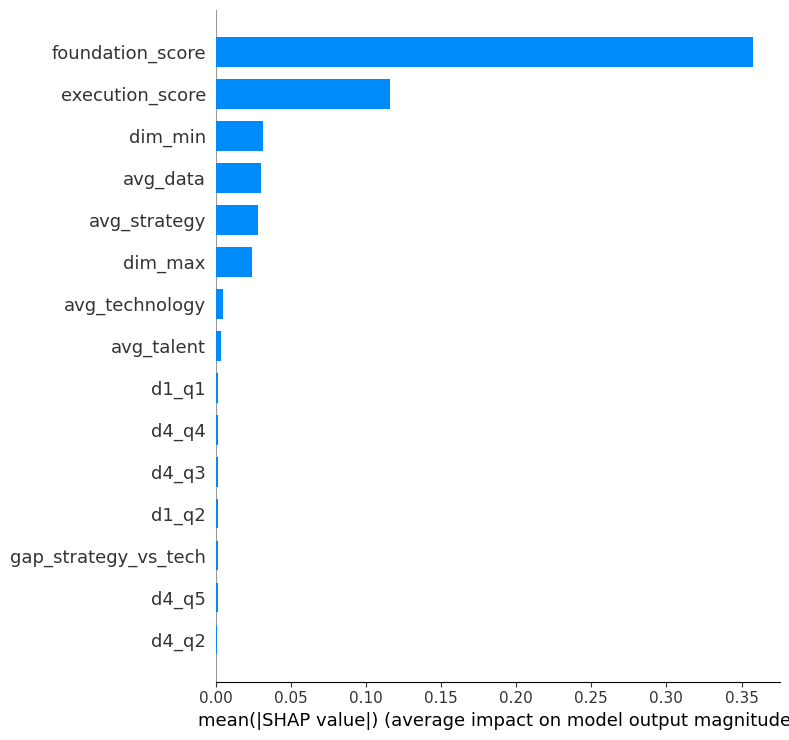

In [2]:
tree_explainer = shap.TreeExplainer(model)
sample = X.sample(n=200, random_state=42)
shap_values = tree_explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type='bar', show=False, max_display=15)
plt.tight_layout()
plt.show()

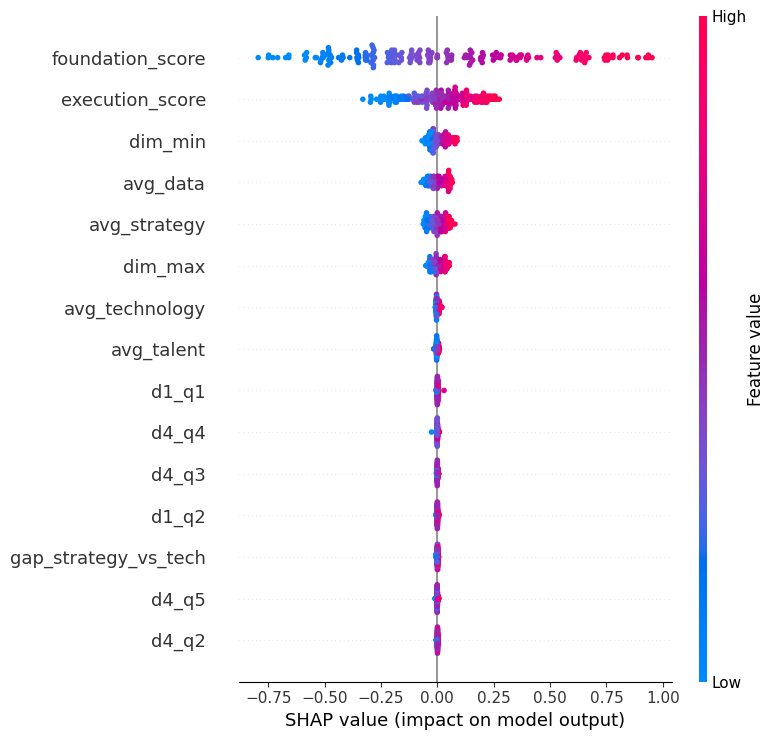

In [3]:
shap.summary_plot(shap_values, sample, show=False, max_display=15)
plt.tight_layout()
plt.show()

## Local explanations — three sample companies

Low / medium / high maturity examples.

In [4]:
ALL_QIDS = [s.question.id for d in FRAMEWORK for s in d.sub_dimensions]

examples = {
    'low_maturity': df_feat.nsmallest(5, 'maturity_score').iloc[0],
    'mid_maturity': df_feat.iloc[(df_feat['maturity_score'] - 3.0).abs().argsort()[:1]].iloc[0],
    'high_maturity': df_feat.nlargest(5, 'maturity_score').iloc[0],
}

for label, row in examples.items():
    answers = {q: int(row[q]) for q in ALL_QIDS}
    exp = explainer_obj.explain(answers, top_n_features=8)
    print(f"\n=== {label.upper()} ===")
    print(f"Sector: {row['sector']}, Size: {row['size']}")
    print(f"Predicted: {exp['predicted_score']:.2f}")
    print('Dimension contributions:')
    for dc in exp['dimension_contributions']:
        sign = '+' if dc['shap_total'] >= 0 else ''
        print(f"  {dc['dimension_name']:20s}  avg={dc['avg_score']:.2f}  SHAP={sign}{dc['shap_total']:.3f}")


=== LOW_MATURITY ===
Sector: manufacturing, Size: startup
Predicted: 1.79
Dimension contributions:
  Data                  avg=2.40  SHAP=-0.054
  Talent & Culture      avg=1.60  SHAP=-0.011
  Technology            avg=1.00  SHAP=-0.009
  Strategy              avg=1.20  SHAP=-0.070
  Processes             avg=2.60  SHAP=-0.008

=== MID_MATURITY ===
Sector: professional_services, Size: small
Predicted: 3.00
Dimension contributions:
  Data                  avg=2.40  SHAP=-0.042
  Talent & Culture      avg=2.80  SHAP=-0.005
  Technology            avg=3.80  SHAP=+0.009
  Strategy              avg=3.60  SHAP=+0.027
  Processes             avg=2.40  SHAP=-0.004

=== HIGH_MATURITY ===
Sector: tech_software, Size: medium
Predicted: 4.60
Dimension contributions:
  Data                  avg=4.80  SHAP=+0.077
  Talent & Culture      avg=4.60  SHAP=+0.012
  Technology            avg=4.40  SHAP=+0.016
  Strategy              avg=4.80  SHAP=+0.074
  Processes             avg=4.40  SHAP=+0.010


## SHAP waterfall for one company

Visual breakdown of how each feature pushed the prediction up or down from the baseline.

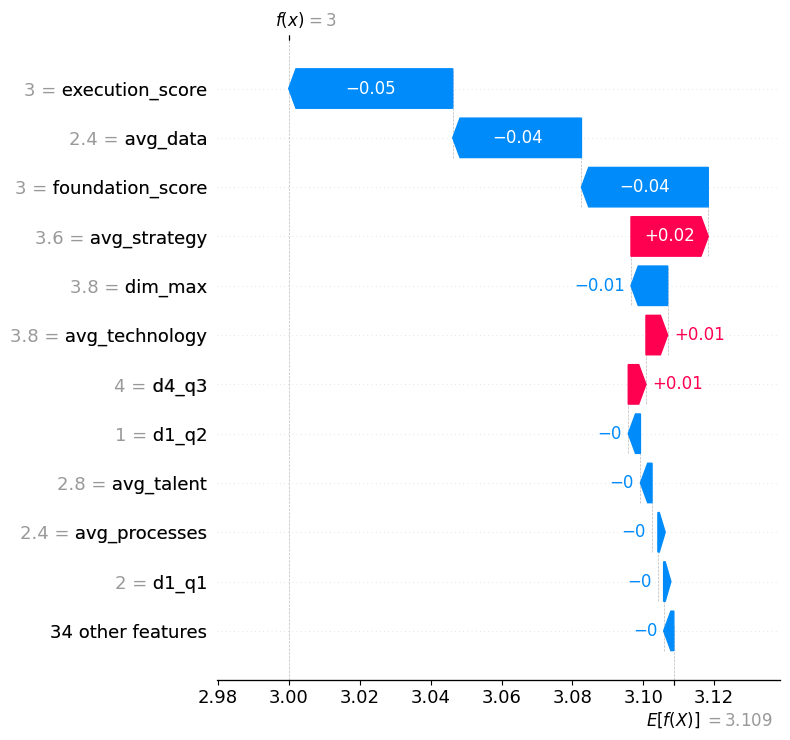

In [5]:
row = df_feat.iloc[(df_feat['maturity_score'] - 3.0).abs().argsort()[:1]].iloc[0]
answers = {q: int(row[q]) for q in ALL_QIDS}
X_one = X.iloc[(df_feat['maturity_score'] - 3.0).abs().argsort()[:1]]

sv_one = tree_explainer(X_one)
shap.plots.waterfall(sv_one[0], max_display=12, show=False)
plt.tight_layout()
plt.show()

## What-if analysis

For the medium-maturity example, simulate improving each dimension by +1 point.

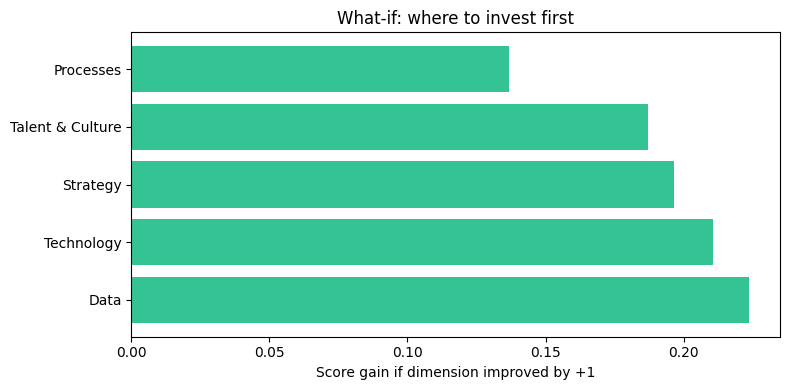

,dimension_name,current_avg,new_avg,current_score,new_score,delta
0,Data,2.4,3.4,2.999919,3.223642,0.223723
1,Technology,3.8,4.8,2.999919,3.210583,0.210664
2,Strategy,3.6,4.6,2.999919,3.196517,0.196598
3,Talent & Culture,2.8,3.8,2.999919,3.187076,0.187156
4,Processes,2.4,3.4,2.999919,3.136577,0.136657


In [6]:
whatifs = explainer_obj.all_what_ifs(answers, delta=1.0)
wi_df = pd.DataFrame(whatifs)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(wi_df['dimension_name'], wi_df['delta'], color='#10b981', alpha=0.85)
ax.set_xlabel('Score gain if dimension improved by +1')
ax.set_title('What-if: where to invest first')
plt.tight_layout()
plt.show()
wi_df[['dimension_name', 'current_avg', 'new_avg', 'current_score', 'new_score', 'delta']]